# Sovereign default database

In [15]:
import matplotlib.pyplot as plt
# Paramétrage des styles utilisés par matplotlib
plt.style.use('default')
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pacoty.mplstyle')

import matplotlib as mpl
mpl.rcParams["axes.prop_cycle"] = mpl.rcParamsDefault["axes.prop_cycle"]


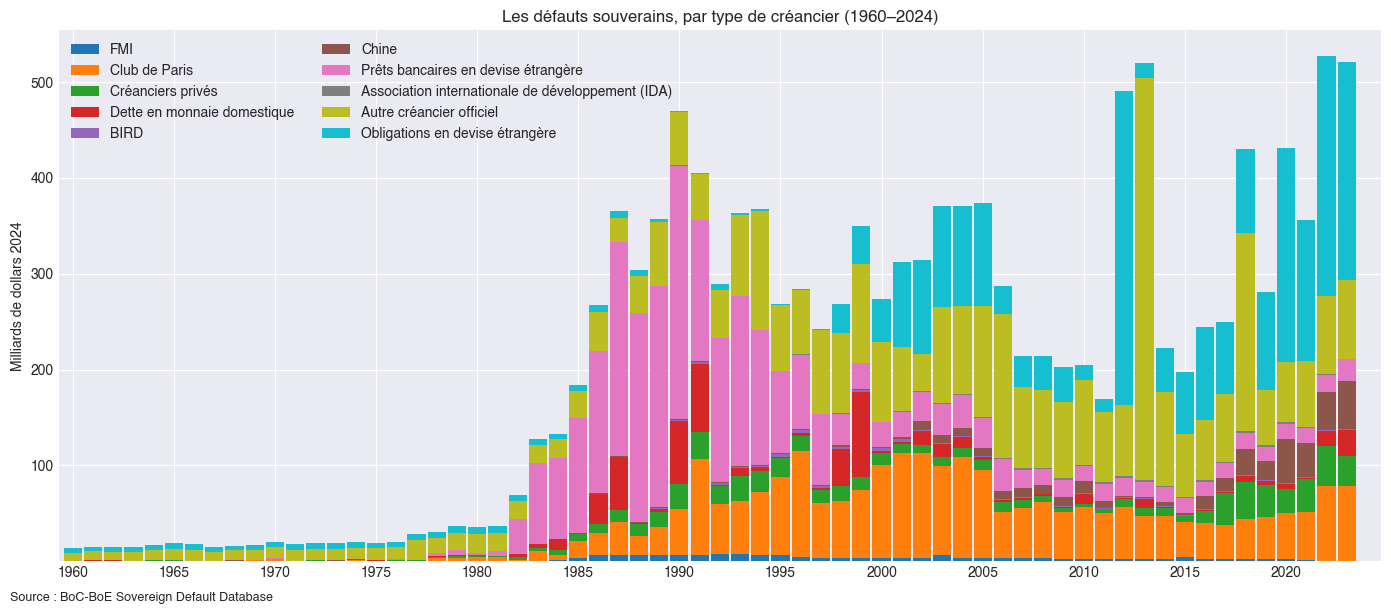

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Charger le CSV (les données commencent ligne 62 -> skiprows=61)
df = pd.read_csv("Data/BoC–BoE_Sovereign_Default_Database_2024.csv", skiprows=61)

# Filtrer World et les années
df = df[
    (df["DEBT_COUNTRY"] == "World") &
    (df["DEBT_YEAR"].between(1960, 2024))
]

# 2) Garder les années et les séries voulues
cols = {
    "DEBT_IMF_2024": "FMI",
    "DEBT_PARIS_CLUB_2024": "Club de Paris",
    "DEBT_PRIVATE_CREDITORS_2024": "Créanciers privés",
    "DEBT_LC_DEBT_2024": "Dette en monnaie domestique",
    "DEBT_IBRD_2024": "BIRD",
    "DEBT_CHINA_2024": "Chine",
    "DEBT_FC_BANK_LOANS_2024": "Prêts bancaires en devise étrangère",
    "DEBT_IDA_2024": "Association internationale de développement (IDA)",
    "DEBT_OTHER_OFFICIAL_CREDITORS_2024": "Autre créancier officiel",
    "DEBT_FC_BONDS_2024": "Obligations en devise étrangère",
}

df = df[df["DEBT_YEAR"].between(1960, 2024)]
df = df[["DEBT_YEAR"] + list(cols.keys())]
df[list(cols.keys())] = df[list(cols.keys())] / 1000

# 3) Nettoyage (chaînes vides -> NaN -> 0)
df = df.replace("", 0).astype(float)

# 4) Renommer pour la légende
df = df.rename(columns=cols)
df["DEBT_YEAR"] = df["DEBT_YEAR"].astype(int)
df = df.set_index("DEBT_YEAR")
df.index.name = None


# 5) Histogramme empilé (barres empilées)

fig, ax = plt.subplots(figsize=(14, 6))

df.plot(
    kind="bar",
    stacked=True,
    width=0.9,
    ax=ax
)

# n’afficher qu’une année sur 5 (ajuste si besoin)
step = 5
ax.set_xticks(range(0, len(df), step))
ax.set_xticklabels(df.index[::step], rotation=0)

plt.ylabel("Milliards de dollars 2024")
plt.title("Les défauts souverains, par type de créancier (1960–2024)")
plt.legend(ncol=2)
fig.text(0.01, -0.01, "Source : BoC-BoE Sovereign Default Database", ha="left", fontsize=9)
fig.tight_layout()
plt.show()


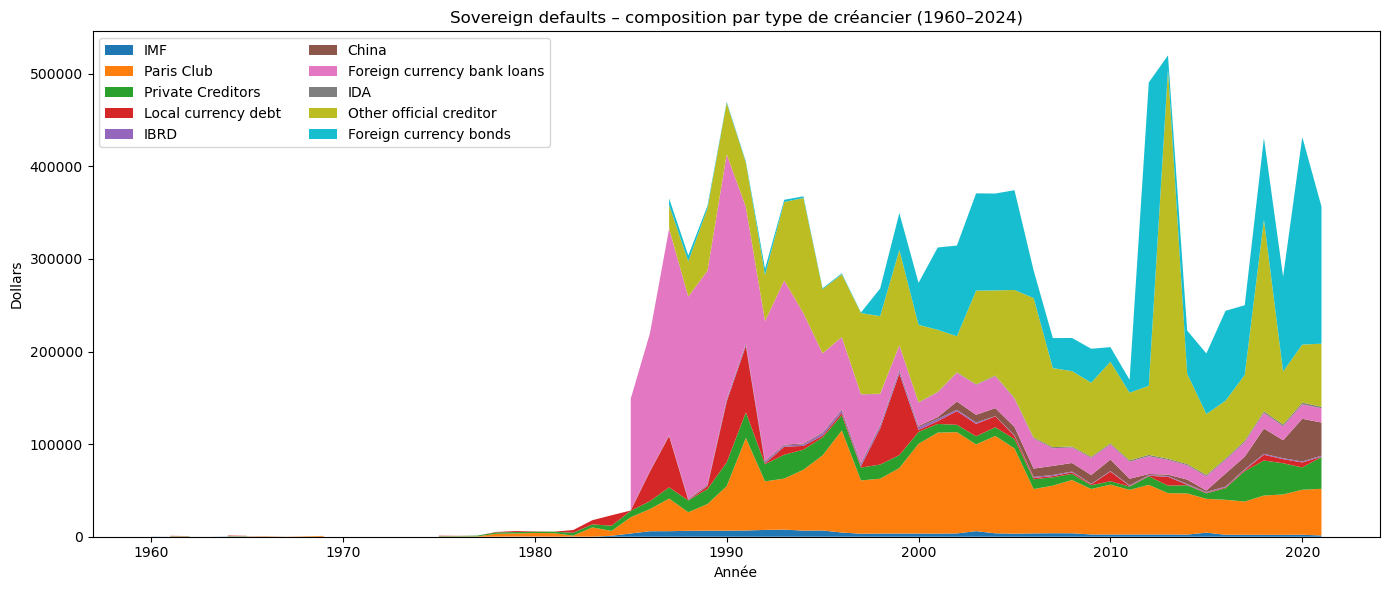

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger le CSV (les données commencent ligne 62)
df = pd.read_csv("Data/BoC–BoE_Sovereign_Default_Database_2024.csv", skiprows=61)

# Filtrer World et les années
df = df[
    (df["DEBT_COUNTRY"] == "World") &
    (df["DEBT_YEAR"].between(1960, 2024))
]

# Séries à tracer
series = {
    "DEBT_IMF_2024": "IMF",
    "DEBT_PARIS_CLUB_2024": "Paris Club",
    "DEBT_PRIVATE_CREDITORS_2024": "Private Creditors",
    "DEBT_LC_DEBT_2024": "Local currency debt",
    "DEBT_IBRD_2024": "IBRD",
    "DEBT_CHINA_2024": "China",
    "DEBT_FC_BANK_LOANS_2024": "Foreign currency bank loans",
    "DEBT_IDA_2024": "IDA",
    "DEBT_OTHER_OFFICIAL_CREDITORS_2024": "Other official creditor",
    "DEBT_FC_BONDS_2024": "Foreign currency bonds",
}

# Garder uniquement ce qui est nécessaire
df = df[["DEBT_YEAR"] + list(series.keys())]

# Nettoyage
df = df.replace("", 0)
df[list(series.keys())] = df[list(series.keys())].astype(float)

# Préparer les données pour stackplot
years = df["DEBT_YEAR"].values
values = [df[col].values for col in series.keys()]

# Plot
plt.figure(figsize=(14, 6))
plt.stackplot(years, values, labels=series.values())

plt.xlabel("Année")
plt.ylabel("Dollars")
plt.title("Sovereign defaults – composition par type de créancier (1960–2024)")
plt.legend(ncol=2, loc="upper left")
plt.tight_layout()
plt.show()


In [3]:
print(df.shape)

(10854, 10)
